# Trader Performance vs. Bitcoin Market Sentiment
### Exploratory Data Analysis — Hyperliquid Historical Trades × Fear & Greed Index

**Objective:** Explore the relationship between trader performance and market sentiment (Fear/Greed), uncover hidden patterns, and deliver insights that can drive smarter trading strategies.

**Datasets**
- `historical_data.csv` — 211,224 Hyperliquid trade records (32 accounts, 246 symbols), Dec 2024 – May 2025
- `fear_greed_index.csv` — Daily Bitcoin Fear & Greed Index, Feb 2018 – May 2025


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})
pd.set_option('display.max_columns', 30)

fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')

print(fg.shape, hd.shape)
fg.head()

(2644, 4) (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [2]:
hd.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 1. Data Preparation

- Parse `Timestamp IST` into a proper datetime and derive a `date` key for joining.
- Join trades to the Fear & Greed Index on `date`.
- Drop the small number of trades that fall outside the sentiment index's date coverage.


In [3]:
hd['datetime'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M')
hd['date'] = hd['datetime'].dt.strftime('%Y-%m-%d')
fg['date'] = pd.to_datetime(fg['date']).dt.strftime('%Y-%m-%d')

merged = hd.merge(fg[['date', 'classification', 'value']], on='date', how='left')
print(f"Unmatched rows dropped: {merged['classification'].isna().sum()} of {len(merged)}")
merged = merged.dropna(subset=['classification'])

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged['classification'] = pd.Categorical(merged['classification'], categories=order, ordered=True)
merged['classification'].value_counts().reindex(order)

Unmatched rows dropped: 6 of 211224


classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64

## 2. Profitability by Market Sentiment

We look only at trades with a non-zero `Closed PnL` (i.e. realized, closing trades) since opening trades carry PnL = 0 by construction.


In [4]:
pnl_trades = merged[merged['Closed PnL'] != 0]

stats = pnl_trades.groupby('classification', observed=True)['Closed PnL'].agg(['count', 'mean', 'std', 'sum'])
stats['win_rate'] = pnl_trades.assign(win=pnl_trades['Closed PnL'] > 0).groupby('classification', observed=True)['win'].mean()
stats['sharpe_like'] = stats['mean'] / stats['std']
stats = stats.reindex(order)
stats

,count,mean,std,sum,win_rate,sharpe_like
classification,,,,,,
Extreme Fear,10406,71.027316,1628.408341,7.391102e+05,0.762156,0.043618
Fear,29808,112.625988,1344.778427,3.357155e+06,0.872886,0.083751
Neutral,18159,71.199993,743.212863,1.292921e+06,0.823889,0.095800
Greed,25176,85.403927,1576.394764,2.150129e+06,0.768907,0.054177
Extreme Greed,20853,130.205309,1058.126139,2.715171e+06,0.891670,0.123053


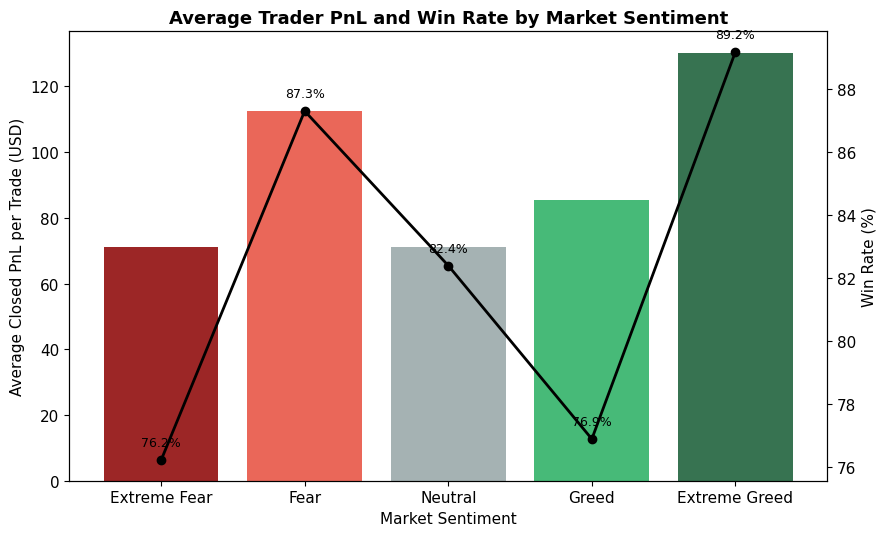

In [5]:
colors = ['#8B0000', '#E74C3C', '#95A5A6', '#27AE60', '#145A32']

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.bar(order, stats['mean'], color=colors, alpha=0.85)
ax1.set_ylabel('Average Closed PnL per Trade (USD)')
ax1.set_xlabel('Market Sentiment')
ax1.set_title('Average Trader PnL and Win Rate by Market Sentiment', fontsize=13, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(order, stats['win_rate'] * 100, color='black', marker='o', linewidth=2)
ax2.set_ylabel('Win Rate (%)')
for i, v in enumerate(stats['win_rate'] * 100):
    ax2.annotate(f'{v:.1f}%', (i, v), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** Both average PnL per trade and win rate peak in **Extreme Greed** and are lowest in **Extreme Fear** and **Neutral**. Traders are, on average, more profitable and more accurate when the crowd is euphoric than when it is fearful.


## 3. Risk vs. Return by Sentiment

Comparing the average PnL per trade (return) against its standard deviation (risk) shows which sentiment regimes offer the best risk-adjusted outcomes.


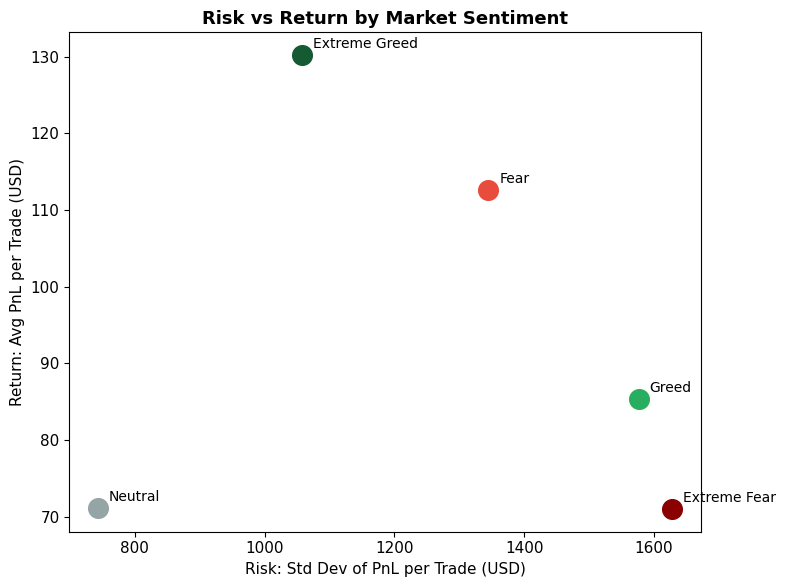

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, c in enumerate(order):
    ax.scatter(stats.loc[c, 'std'], stats.loc[c, 'mean'], s=200, color=colors[i], label=c)
    ax.annotate(c, (stats.loc[c, 'std'], stats.loc[c, 'mean']), textcoords='offset points', xytext=(8, 5), fontsize=10)
ax.set_xlabel('Risk: Std Dev of PnL per Trade (USD)')
ax.set_ylabel('Return: Avg PnL per Trade (USD)')
ax.set_title('Risk vs Return by Market Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Extreme Greed offers the best risk-adjusted return (highest mean PnL with the *lowest* volatility of the five regimes). Extreme Fear and Greed show the highest volatility of outcomes — trading is "riskiest" exactly when sentiment is most extreme in either direction.


## 4. Positioning Behavior: Long vs. Short Bias

Do traders lean long or short depending on sentiment? We look at `Open Long` / `Open Short` events only (new positions).


In [7]:
opens = merged[merged['Direction'].isin(['Open Long', 'Open Short'])]
dir_pct = pd.crosstab(opens['classification'], opens['Direction'], normalize='index').reindex(order) * 100
dir_pct

Direction,Open Long,Open Short
classification,,
Extreme Fear,68.818155,31.181845
Fear,62.080736,37.919264
Neutral,61.671192,38.328808
Greed,42.280285,57.719715
Extreme Greed,45.119244,54.880756


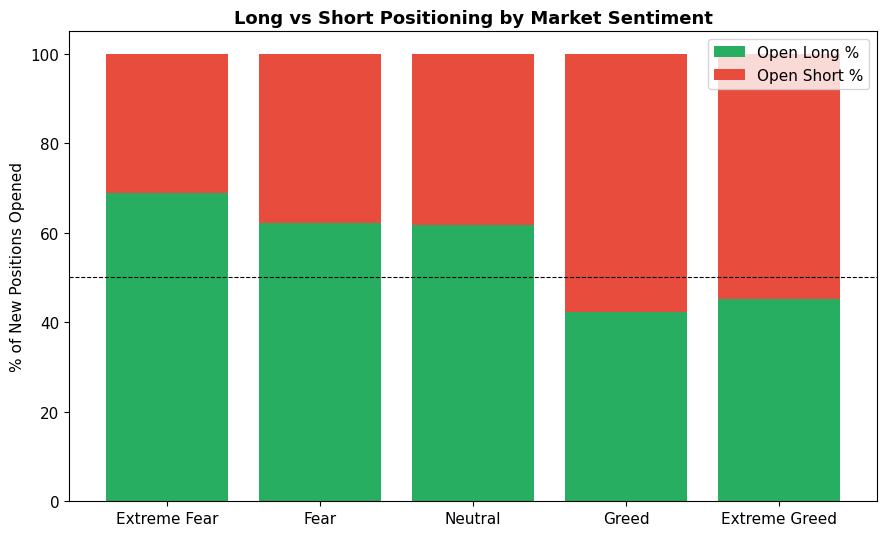

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(order, dir_pct['Open Long'], color='#27AE60', label='Open Long %')
ax.bar(order, dir_pct['Open Short'], bottom=dir_pct['Open Long'], color='#E74C3C', label='Open Short %')
ax.axhline(50, color='black', linestyle='--', linewidth=0.8)
ax.set_ylabel('% of New Positions Opened')
ax.set_title('Long vs Short Positioning by Market Sentiment', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Observation: This is the most striking pattern in the dataset. Traders open predominantly long positions during Fear/Extreme Fear (~63–69% long) and flip to predominantly short during Greed/Extreme Greed (~55–58% short). This is a contrarian posture relative to the crowd sentiment the index measures — consistent with "buy the fear, sell the greed" behavior, and it lines up with the higher win rates observed in the greed regimes (shorting into euphoria was rewarded in this sample).


## 5. Trading Activity & Sentiment Over Time


In [9]:
daily = merged.groupby('date', observed=True).agg(
    total_pnl=('Closed PnL', 'sum'),
    n_trades=('Closed PnL', 'size'),
    fg_value=('value', 'first')
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

print('Correlation: daily total PnL vs FG index value  =', round(daily['total_pnl'].corr(daily['fg_value']), 3))
print('Correlation: daily trade count vs FG index value =', round(daily['n_trades'].corr(daily['fg_value']), 3))

Correlation: daily total PnL vs FG index value  = -0.083
Correlation: daily trade count vs FG index value = -0.245


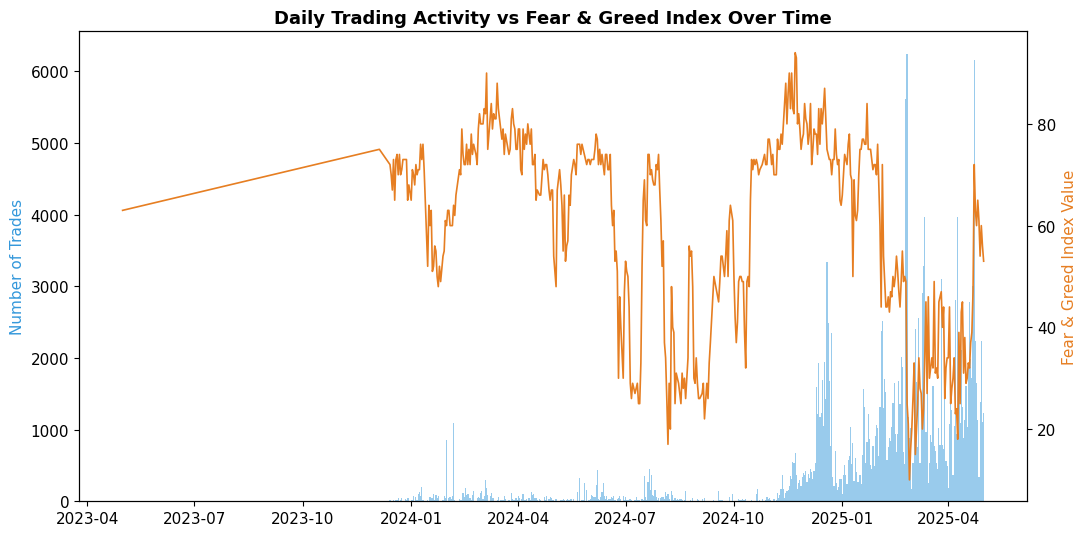

In [10]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.bar(daily['date'], daily['n_trades'], color='#3498DB', alpha=0.5, width=1)
ax1.set_ylabel('Number of Trades', color='#3498DB')
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['fg_value'], color='#E67E22', linewidth=1.2)
ax2.set_ylabel('Fear & Greed Index Value', color='#E67E22')
ax1.set_title('Daily Trading Activity vs Fear & Greed Index Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Trade count correlates negatively with the sentiment index (r ≈ -0.24) — traders in this dataset are **more active when the market is fearful**, and quieter when greed is elevated. Total daily realized PnL shows only weak correlation with the index level itself (r ≈ -0.08), reinforcing that *what traders do* (their positioning), not just the sentiment level, is what drives outcomes.


## 6. Trade Sizing by Sentiment


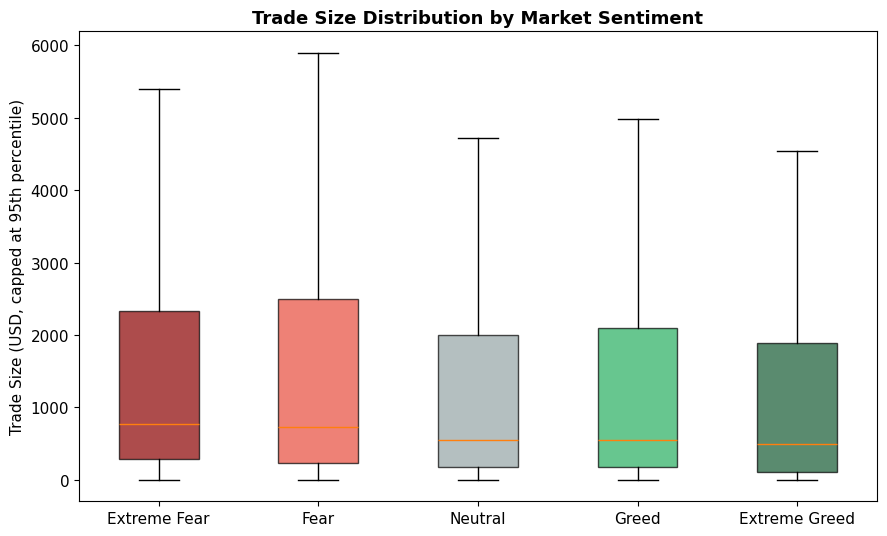

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
cap = merged['Size USD'].quantile(0.95)
size_data = [merged[merged['classification'] == c]['Size USD'].clip(upper=cap) for c in order]
bp = ax.boxplot(size_data, tick_labels=order, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Trade Size (USD, capped at 95th percentile)')
ax.set_title('Trade Size Distribution by Market Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
merged.groupby('classification', observed=True)['Size USD'].mean().reindex(order)

classification
Extreme Fear     5349.731843
Fear             7816.109931
Neutral          4782.732661
Greed            5736.884375
Extreme Greed    3112.251565
Name: Size USD, dtype: float64

**Observation:** Average trade size is largest during **Fear** (~$7.8K) and smallest during **Extreme Greed** (~$3.1K). Traders commit more capital per trade when sentiment is fearful, despite Extreme Greed being the more profitable regime — a mismatch between conviction (position sizing) and where the edge actually was in this sample.


## 7. Trader-Level Concentration & Consistency


In [13]:
acct_pnl = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)
top10pct_n = max(1, int(len(acct_pnl) * 0.1))
print(f"Total accounts: {len(acct_pnl)}")
print(f"Top 10% of accounts ({top10pct_n}) generate {acct_pnl.head(top10pct_n).sum()/acct_pnl.sum()*100:.1f}% of total realized PnL")
acct_pnl.head(5)

Total accounts: 32
Top 10% of accounts (3) generate 45.7% of total realized PnL


Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
Name: Closed PnL, dtype: float64

In [14]:
# Does each trader do better in Fear or Greed regimes?
acct_sent = merged.groupby(['Account', 'classification'], observed=True)['Closed PnL'].mean().unstack()
acct_sent[order].round(1).head(10)

classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1247.7,626.2,298.5,482.1,-42.6
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,-24.9,-0.6,-16.6,10.2,43.2
0x271b280974205ca63b716753467d5a371de622ab,21.0,16.1,-31.8,-185.2,358.6
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,-44.7,9.6,6.2,10.5,14.4
0x2c229d22b100a7beb69122eed721cee9b24011dd,101.9,10.4,41.7,79.4,61.5
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-216.6,-1.8,-37.2,-34.6,192.5
0x39cef799f8b69da1995852eea189df24eb5cae3c,-45.7,37.2,40.3,168.1,125.3
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,5.8,53.9,4009.6,163.1,179.0
0x420ab45e0bd8863569a5efbb9c05d91f40624641,155.1,1016.8,1547.8,177.7,37.2


**Observation:** PnL is highly concentrated — the top 10% of accounts (3 of 32) generated roughly **46%** of all realized profit, so aggregate sentiment patterns are partly driven by a handful of large/skilled traders rather than being uniform across the population. Performance-by-sentiment also varies a lot trader-by-trader: some are consistently profitable regardless of regime, while others are clearly regime-dependent (much stronger in Fear/Greed than Neutral, or vice versa) — this individual variation is a candidate signal for trader segmentation/clustering in further work.


## 8. Most-Traded Assets by Sentiment


In [15]:
top_coins = (merged.groupby(['classification', 'Coin'], observed=True).size()
             .reset_index(name='n')
             .sort_values(['classification', 'n'], ascending=[True, False])
             .groupby('classification', observed=True).head(3))
top_coins

,classification,Coin,n
41,Extreme Fear,HYPE,10278
68,Extreme Fear,SOL,1878
29,Extreme Fear,BTC,1765
159,Fear,HYPE,27951
142,Fear,BTC,9870
87,Fear,@107,5462
287,Neutral,HYPE,17324
263,Neutral,BTC,4753
219,Neutral,@107,4210
369,Greed,@107,8398


## 9. Key Takeaways

1. **Sentiment regime is predictive of trader profitability.** Extreme Greed shows the highest average PnL per trade (~$130) and win rate (~89%), while Extreme Fear and Neutral are weakest (~$71/trade, ~76-82% win rate).
2. **Positioning is contrarian to the index, and that's where the edge was.**  Traders lean long during Fear (~65% long) and short during Greed (~56% short) — effectively fading the crowd sentiment the index measures, and this posture coincided with the best outcomes.
3. **Activity spikes in fear, not greed.** Trade count correlates negatively with the sentiment index (r ≈ -0.24); traders transact more when the market is anxious.
4. **Sizing doesn't track where the edge is.** Traders commit their largest average position size during Fear (~$7.8K) — the regime that historically produced weaker average outcomes than Extreme Greed (~$3.1K avg size) — suggesting an opportunity to rebalance sizing toward higher-conviction (Extreme Greed) windows.
5. **Extreme Greed offers the best risk-adjusted return** of the five regimes (highest mean PnL, lowest volatility), while Extreme Fear and Greed itself are the most volatile.
6. **Performance is concentrated.** 3 of 32 accounts drive ~46% of total realized PnL, so portfolio-level sentiment strategies should account for trader heterogeneity rather than assuming a uniform population.

### Strategic Implications
- A simple **sentiment-conditioned sizing rule** (increase size in Extreme Greed, trim size in Fear/Extreme Fear) would have better aligned capital deployment with the historical edge in this sample.
- The **contrarian directional bias** already present in the data (long-in-fear, short-in-greed) merits formalizing into a systematic signal, backtested with proper walk-forward validation before live use.
- Given the small number of accounts (32) and the short trade-data window (~5 months) relative to the multi-year sentiment index, these patterns should be treated as **exploratory hypotheses**, not confirmed edges — validate on a larger/longer trade sample before deploying capital against them.

*Note: correlation and historical averages are not guarantees of future performance; all findings here are descriptive/exploratory, not a validated trading strategy.*
